# COE 592

##  ASSIGNMENT 1


**Description:**

  In this hands-on assignment, you will apply the concepts of feature detection, description and matching methods using OpenCV2 library, and re-assemble an image's slices to match the original image's snapshot

**Deliverables**

  * Completed version of this notebook, renamed to `COE592-Assg1-<Student1_ID>-<Student2_ID>.ipynb`
  * A short report following the below outline:
    * Problem Statement
    * Solution Design and Methodology
      * Describe your proposed solution using a flowchart and psuedocode
    * Experiments and Results
      * Try your solution on some sample images, and include the snapshots of intermediate results, the final re-assembled image, and similarity scores
      * Refer to the hands-on tutorial to see how to implement matching and to show matching results
    * Team details: Names and IDs of the team
  * The original images you used in your work
  

**Submission Instructions:**

Please submit all the deliverables on Blackboard (as individual files and not as a zip/rar archive)


**Credits:**

Prepared by Dr. Abdul Jabbar Siddiqui


In [1]:
!pip install requests

In [2]:
import numpy as np
import cv2
import random
import matplotlib.pyplot as plt
import requests

# from google.colab.patches import cv2_imshow

In [3]:
# to mount your google drive (requires Google log in)
# Alternatively, use the "Mount Drive" button from the "Files" tab on the left menu bars
# from google.colab import drive
# drive.mount('/drive')

In [4]:
# Copy and save path to your images directory in mypath
# mypath = '/content/drive/MyDrive/COE595/colab-teaching/'

# Load Images

In [5]:

# Read the larger scene image in which you want to find the query_img object in scene_img
# scene_img = cv2.imread(mypath+'/T3_drone.jpg')
img_link = "https://raw.githubusercontent.com/officialar33b/COE-512-Ass1/main/drone.jpg"

scene_img = cv2.imdecode(
    np.frombuffer(requests.get(img_link).content, np.uint8), 
    cv2.IMREAD_COLOR
)

In [6]:
print(scene_img is None)

False


# Slice and Shuffle Scene Image

In [7]:
# Convert images to grayscale (recommended for ease of using opencv feature descriptors like SIFT, ORB, SURF, etc.)

scene_img_bw = cv2.cvtColor(scene_img, cv2.COLOR_BGR2GRAY)


# Function to take a scene_img and split it into multiple slices, returns a shuffled list of slices
def slice_and_shuffle(inimg, doShuffle=True):
  M = inimg.shape[0] // 5
  N = inimg.shape[1] // 5
  # M=5, N=5, to make 25 tiles from a given inimg

  tiles = [inimg[x:x+M,y:y+N] for x in range(0,inimg.shape[0],M) for y in range(0,inimg.shape[1],N)]

  random.shuffle(tiles)

  return tiles

slices_list = slice_and_shuffle(scene_img_bw) # You cannot manipulate this list, but you may manipulate scene_img_bw if needed

### Display Original Image

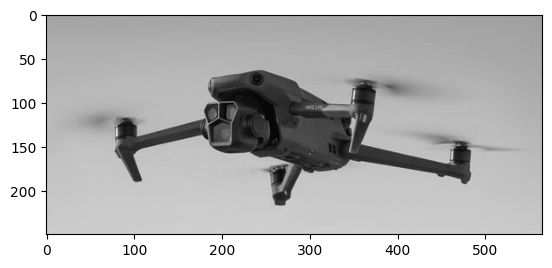

In [8]:
scene_img_bw = cv2.cvtColor(scene_img, cv2.COLOR_BGR2GRAY)
plt.imshow(scene_img_bw, cmap='gray')

### Sharpening the Image!?

In [9]:
# scene_img_bw = np.float32(scene_img_bw)/255.
# # sharpening filter
# N = 3
# g = -np.ones((N,N))/(N**2)
# g[(N-1)//2,(N-1)//2] += 2

# scene_img_bw = cv2.filter2D(scene_img_bw, -1, g)
# scene_img_bw = np.clip(scene_img_bw * 255.0, 0, 255).astype(np.uint8)
# plt.imshow(np.clip(scene_img_bw), cmap='gray')

# Tasks to do:
  * Complete the function `reassemble_slices(...)`: using feature detection and matching, re-assemble the slices in `slices_list` to produce the `reassembled_img`
    
    * Hint: select an appropriate feature detector/descriptor and use feature matching to match each slice with the respective region in `scene_img_bw`
    * Note:
      * your solution must not be based on prior knowledge of the slicing sequence or shuffling order. The re-assembling should be based on matching
      * Your solution must have a verification step to deal with "confused" matches and correct those
      * Your solution must not be specific to one image, it should be generic enough to work with different images



In [ ]:
# YOUR TASK TO DO

def reassemble_slices(slist = slices_list, orig_img = scene_img_bw):

  # Your code here...

  # ## SIFT Implementation
  # reassembled_img = np.zeros_like(orig_img) # dummy init.

  # ## 5x5 grid.
  # M = orig_img.shape[0] // 5
  # N = orig_img.shape[1] // 5

  # ## Instatiate SIFT detector
  # # sift = cv2.SIFT_create(nfeatures=1000)
  # sift = cv2.SIFT_create(nfeatures=1000, 
  # contrastThreshold=0.01, 
  # edgeThreshold=10, 
  # sigma=1.6)
  # scene_kp, scene_des = sift.detectAndCompute(orig_img, None)

  # ## Brute Force Matcher
  # # matcher = cv2.BFMatcher()

  # ## Using Tuned FLANN Matcher
  # index_params = dict(algorithm=1, trees=10)
  # search_params = dict(checks=100)
  # matcher = cv2.FlannBasedMatcher(index_params, search_params)


  # # Hint: you may use each slice as a query_img
  # for query_img in slist:
  #   query_kp, query_des = sift.detectAndCompute(query_img, None)
  #   if query_des is None or len(query_des) <2:
  #     continue

  #   matches = matcher.knnMatch(query_des, scene_des, k=2)

  #   good_matches = list()
  #   for m, n in matches:
  #     if m.distance < .75 * n.distance:
  #       good_matches.append(m)

  #   if len(good_matches) <2:
  #     continue

  #   query_pts = np.float32([query_kp[m.queryIdx].pt for m in good_matches])
  #   scene_pts = np.float32([scene_kp[m.trainIdx].pt for m in good_matches])

  #   offsets = scene_pts - query_pts
  #   median_x = np.median(offsets[:, 0])
  #   median_y = np.median(offsets[:, 1])

  #   start_col = int(round(median_x /N)*N)
  #   start_row = int(round(median_y /M)*M)

  #   # Now make the image.
  #   if 0 <= start_row < orig_img.shape[0] and 0 <= start_col < orig_img.shape[1]:
  #     reassembled_img[start_row:start_row+M, start_col:start_col+N] = query_img

  

  # SIFT + Cross-Correlation Implementation
  reassembled_img = np.zeros_like(orig_img) # dummy init.
  rows, cols = 5,5
  M, N = orig_img.shape[0] // rows, orig_img.shape[1] // cols

  # Grid occupancy map to guarantee 1-to-1 tile placement
  grid_occupied = np.zeros((rows, cols), dtype=bool)
  unassigned_tiles = []
  
  # Extract SIFT features for the target original scene
  sift = cv2.SIFT_create(nfeatures=5000, contrastThreshold=0.01)
  scene_kp, scene_des = sift.detectAndCompute(orig_img, None)
  matcher = cv2.BFMatcher()

  # --- PHASE 1: High-Confidence SIFT Feature Matching ---
  for tile in slist:
      tile_kp, tile_des = sift.detectAndCompute(tile, None)
      placed = False
      
      if tile_des is not None and len(tile_des) >= 2:
          matches = matcher.knnMatch(tile_des, scene_des, k=2)
          
          # Lowe's Ratio Test
          good_matches = [m for m, n in matches if m.distance < 0.75 * n.distance]
          
          if len(good_matches) >= 2:
              pts_tile = np.float32([tile_kp[m.queryIdx].pt for m in good_matches])
              pts_scene = np.float32([scene_kp[m.trainIdx].pt for m in good_matches])
              
              # Robust median offset calculation (eliminates false outlier matches)
              offsets = pts_scene - pts_tile
              median_x = np.median(offsets[:, 0])
              median_y = np.median(offsets[:, 1])
              
              # Snap offset to grid indices
              r = int(round(median_y / M))
              c = int(round(median_x / N))
              
              # Assign if within bounds and slot is open
              if 0 <= r < rows and 0 <= c < cols and not grid_occupied[r, c]:
                  start_r, start_c = r * M, c * N
                  reassembled_img[start_r:start_r+M, start_c:start_c+N] = tile[:M, :N]
                  grid_occupied[r, c] = True
                  placed = True
                  
      if not placed:
          unassigned_tiles.append(tile)

  # --- PHASE 2: Cross-Correlation Matcher for Featureless/Sky Tiles ---
  empty_slots = [(r, c) for r in range(rows) for c in range(cols) if not grid_occupied[r, c]]
  
  for tile in unassigned_tiles:
      best_score = -1.0
      best_slot = None
      
      for r, c in empty_slots:
          target_crop = orig_img[r*M:(r+1)*M, c*N:(c+1)*N]
          
          if target_crop.shape == tile[:M, :N].shape:
              # Compare pixel intensity distribution across remaining empty slots
              res = cv2.matchTemplate(target_crop, tile[:M, :N], cv2.TM_CCOEFF_NORMED)
              score = res[0][0]
              
              if score > best_score:
                  best_score = score
                  best_slot = (r, c)
                  
      if best_slot is not None:
          r, c = best_slot
          start_r, start_c = r * M, c * N
          reassembled_img[start_r:start_r+M, start_c:start_c+N] = tile[:M, :N]
          grid_occupied[r, c] = True
          empty_slots.remove(best_slot)


  


  return reassembled_img


# reassembled_img =  # your final reassembled image should be returned as reassembled_img, should be an opencv format
reassembled_img = reassemble_slices(slices_list, scene_img_bw)

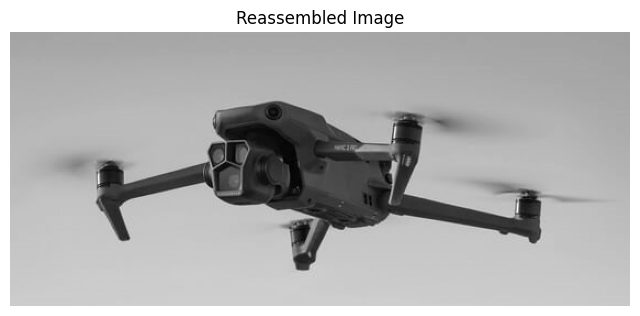

In [11]:
plt.figure(figsize=(8, 8))
plt.imshow(reassembled_img, cmap='gray')
plt.title("Reassembled Image")
plt.axis('off')
plt.show()

# Testing

  * Compare your `reassembled_img` with `scene_img_bw`
  * Use scikit-image library's Structural Similarity Index (SSIM) to compare
    * Read https://scikit-image.org/docs/stable/api/skimage.metrics#skimage.metrics.structural_similarity for more info

In [12]:
# This function compares scene_img_bw and reassembled_img to check for correctness in re-assembling

from skimage.metrics import structural_similarity

def check_reassembly(prod=reassembled_img, orig=scene_img_bw):

  # Use scikit-image library's Structural Similarity Index (SSIM) to compare
  # Read https://scikit-image.org/docs/stable/api/skimage.metrics#skimage.metrics.structural_similarity for more info

  score = structural_similarity(reassembled_img, scene_img_bw)


  return score

In [13]:
# You may test your reassembled_img's similarity to the original scene_img_bw

print(check_reassembly(reassembled_img, scene_img_bw))

1.0


Since the image is an actual crop of the existing image, this approach giving a 100% or 1.0 similarity score is to be expected. If the image was a different image representing the same object from another position of something similar to panaroma stitching, the results would have been a little bit more realistic.